## Etape 1 : Chargement des données MNIST

In [18]:
import keras
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

#  Shape des données
print('Shape x_train :', x_train.shape)
print('Shape y_train :', y_train.shape)
print('Shape x_test  :', x_test.shape)
print('Shape y_test  :', y_test.shape)

# Nombre d'images
print('\nNombre d\'images en entraînement :', x_train.shape[0])
print('Nombre d\'images en test         :', x_test.shape[0])

Shape x_train : (60000, 28, 28)
Shape y_train : (60000,)
Shape x_test  : (10000, 28, 28)
Shape y_test  : (10000,)

Nombre d'images en entraînement : 60000
Nombre d'images en test         : 10000


 Histogramme de digit

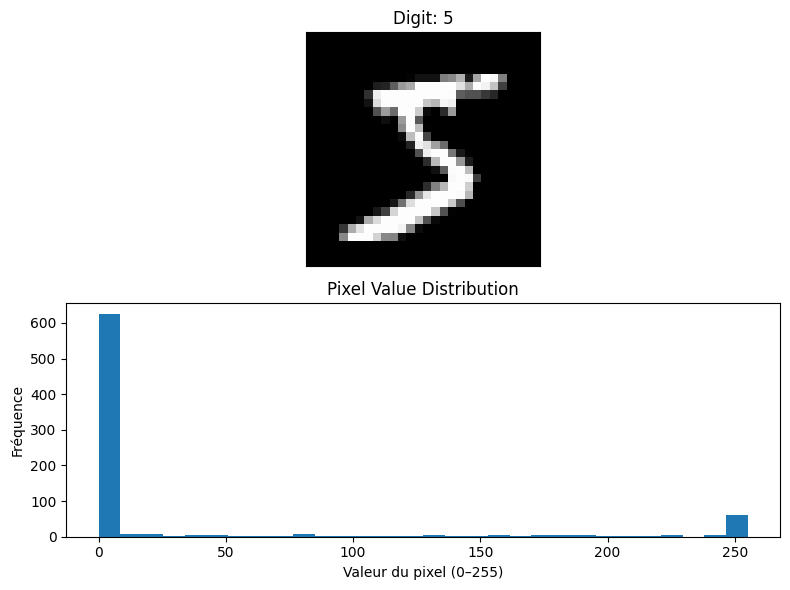

In [19]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 6))
plt.subplot(2, 1, 1)
plt.imshow(x_train[0], cmap='gray', interpolation='none')
plt.title('Digit: {}'.format(y_train[0]))
plt.xticks([])
plt.yticks([])

plt.subplot(2, 1, 2)
plt.hist(x_train[0].reshape(784), bins=30)
plt.title('Pixel Value Distribution')
plt.xlabel('Valeur du pixel (0–255)')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

### Interprétation de l'histogramme
L'histogramme montre une **distribution bimodale** :
 On a une grande majorité des pixels ont une valeur proche de **0**.
 Un petit pic de pixels a des valeurs proches de **255** .
 Cela confirme que les images MNIST sont des chiffres blancs sur fond noir avec très peu de niveaux de gris intermédiaires.

Redimensionnement et normalisation

In [21]:
# Redimensionnement :
x_train = x_train.reshape(x_train.shape[0], 784).astype('float32')
x_test  = x_test.reshape(x_test.shape[0], 784).astype('float32')

# Normalisation :
x_train = x_train / 255.0
x_test  = x_test / 255.0

print('Nouveau shape x_train :', x_train.shape)
print('Nouveau shape x_test  :', x_test.shape)
print('Min pixel :', x_train.min(), 'et  Max pixel :', x_train.max())

Nouveau shape x_train : (60000, 784)
Nouveau shape x_test  : (10000, 784)
Min pixel : 0.0 et  Max pixel : 0.003921569


Affichage après normalisation

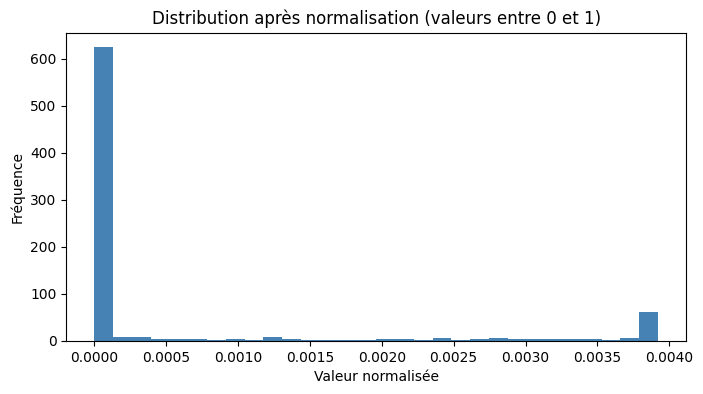

Aperçu des 10 premières valeurs du sample 0 : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [23]:
fig = plt.figure(figsize=(8, 4))
plt.hist(x_train[0], bins=30, color='steelblue')
plt.title('Distribution après normalisation (valeurs entre 0 et 1)')
plt.xlabel('Valeur normalisée')
plt.ylabel('Fréquence')
plt.show()


print('Aperçu des 10 premières valeurs du sample 0 :', x_train[0][:10])

 One-Hot Encoding des labels

> Add blockquote



In [12]:
from keras.utils import to_categorical

nb_classes = 10

y_train_cat = to_categorical(y_train, nb_classes)
y_test_cat  = to_categorical(y_test,  nb_classes)

print('Shape y_train après one-hot :', y_train_cat.shape)  # (60000, 10)
print('Shape y_test  après one-hot :', y_test_cat.shape)   # (10000, 10)
print()
print('Label original y_train[0] :', y_train[0])
print('Encodage one-hot          :', y_train_cat[0])
# Exemple : si y_train[0] = 5  →  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

Shape y_train après one-hot : (60000, 10)
Shape y_test  après one-hot : (10000, 10)

Label original y_train[0] : 5
Encodage one-hot          : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


 Construction du modèle MLP

In [24]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()

# Couche d'entrée  et couche cachée :
model.add(Dense(512, activation='relu', input_shape=(784,)))

# Couche de sortie :
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

 Compilation et entraînement

In [25]:
from keras.optimizers import SGD

#  l'optimiseur SGD
sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

# Compilation du modèle
model.compile(
    loss='categorical_crossentropy',
    optimizer=sgd,
    metrics=['accuracy']
)

# Entraînement
history = model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=20,
    verbose=1,
    validation_data=(x_test, y_test_cat)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1162 - loss: 2.2988 - val_accuracy: 0.1135 - val_loss: 2.2980
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1155 - loss: 2.2976 - val_accuracy: 0.1135 - val_loss: 2.2967
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1172 - loss: 2.2963 - val_accuracy: 0.1135 - val_loss: 2.2949
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.1138 - loss: 2.2949 - val_accuracy: 0.1135 - val_loss: 2.2933
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.1215 - loss: 2.2929 - val_accuracy: 0.1135 - val_loss: 2.2914
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1165 - loss: 2.2910 - val_accuracy: 0.1135 - val_loss: 2.2892
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1170 - loss: 2.2886 - val_accuracy: 0.1135 - val_loss: 2.2867
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1375 - loss: 2.2860 - val_accu

##Evaluation sur l'ensemble de test

---



In [26]:
# Evaluation du modèle
score = model.evaluate(x_test, y_test_cat, verbose=0)

print('Loss sur le test  : {:.4f}'.format(score[0]))
print('Accuracy  sur le test : {:.2f}%'.format(score[1] * 100))

Loss sur le test  : 2.1641
Accuracy  sur le test : 36.50%
